# Extra Curriculum - Function Study

This standalone notebook evaluates 4 activation functions for a compact PyTorch MLP on `dataset_stratified.csv`. Activations compared:
- ReLU
- GELU
- SiLU/Swish
- Tanh

The comparison keeps the architecture, preprocessing, regularization, and training protocol fixed. The optimizer is **plain SGD only**.

> **Repository alignment:** This notebook is structured for the standalone `01-model-benchmarking-and-error-analysis` project root. Inputs are read from `data/raw/covertype/` or `data/processed/`; metrics, runtime tables, model-comparison artifacts, confusion matrices, and figures are written to the project-local `results/` and `figures/` folders.


In [1]:
# Project-local configuration, paths, and imports
import os
import sys
from pathlib import Path

MODULE_NAME = "01-model-benchmarking-and-error-analysis"
NOTEBOOK_SLUG = "08_activation_functions_extra_credit"


def _find_project_root(start: str | Path | None = None) -> Path:
    """Find the 01-model-benchmarking-and-error-analysis project root."""
    start_path = Path(start or os.environ.get("MODEL_BENCHMARK_ROOT", Path.cwd())).resolve()
    for candidate in [start_path, *start_path.parents]:
        if candidate.name == MODULE_NAME and (candidate / "notebooks").exists():
            return candidate
        if (
            (candidate / "README.md").exists()
            and (candidate / "notebooks").exists()
            and (candidate / "src").exists()
            and (candidate / "scripts").exists()
        ):
            return candidate
    return start_path


PROJECT_ROOT = _find_project_root()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

try:
    from src.data.project_paths import get_paths
except Exception as exc:
    raise ImportError(
        "Could not import src.data.project_paths. Run this notebook from inside "
        "01-model-benchmarking-and-error-analysis or set MODEL_BENCHMARK_ROOT."
    ) from exc

PATHS = get_paths(PROJECT_ROOT)

RAW_DATA_DIR = PATHS.raw_data_dir
PROCESSED_DATA_DIR = PATHS.processed_data_dir
DATASET_STRATIFIED_PATH = PATHS.dataset_stratified_path
DATASET_REMAINDER_PATH = PATHS.dataset_remainder_path

RESULTS_METRICS_DIR = PATHS.results_metrics_dir
RESULTS_RUNTIME_DIR = PATHS.results_runtime_dir
RESULTS_MODEL_COMPARISON_DIR = PATHS.results_model_comparison_dir
RESULTS_CONFUSION_MATRICES_DIR = PATHS.results_confusion_matrices_dir

FIG_EDA_DIR = PATHS.figures_eda_dir
FIG_LEARNING_CURVES_DIR = PATHS.figures_learning_curves_dir
FIG_MODEL_COMPLEXITY_DIR = PATHS.figures_model_complexity_dir
FIG_CONFUSION_MATRICES_DIR = PATHS.figures_confusion_matrices_dir
FIG_RUNTIME_DIR = PATHS.figures_runtime_dir

REPORTS_DIR = PATHS.reports_dir

# Backward-compatible aliases used by the original notebooks.
# New output writes below are routed to the specific category folders above.
OUT_DIR = RESULTS_METRICS_DIR
RESULTS_DIR = RESULTS_METRICS_DIR
FIG_DIR = FIG_EDA_DIR if NOTEBOOK_SLUG.startswith(("01_", "02_")) else FIG_MODEL_COMPLEXITY_DIR

for directory in [
    RAW_DATA_DIR,
    PROCESSED_DATA_DIR,
    RESULTS_METRICS_DIR,
    RESULTS_RUNTIME_DIR,
    RESULTS_MODEL_COMPARISON_DIR,
    RESULTS_CONFUSION_MATRICES_DIR,
    FIG_EDA_DIR,
    FIG_LEARNING_CURVES_DIR,
    FIG_MODEL_COMPLEXITY_DIR,
    FIG_CONFUSION_MATRICES_DIR,
    FIG_RUNTIME_DIR,
    REPORTS_DIR,
]:
    directory.mkdir(parents=True, exist_ok=True)

# Input protocol:
# - Notebook 01 reads raw covtype.data and creates dataset_stratified.csv + dataset_remainder.csv.
# - Notebooks 02-08 read dataset_stratified.csv for train/validation.
# - Model notebooks also read dataset_remainder.csv for untouched final testing.
DATA_PATH_RAW = RAW_DATA_DIR / "covtype.data"
DATA_PATH = DATASET_STRATIFIED_PATH
DATA_PATH_TEST = DATASET_REMAINDER_PATH
TARGET_COL = "Cover_Type"

print("PROJECT_ROOT:", PROJECT_ROOT)
print("DATA_PATH:", DATA_PATH)
if NOTEBOOK_SLUG not in {'02_eda_dataset_sampled', '01_eda_dataset_original'}:
    print("DATA_PATH_TEST:", DATA_PATH_TEST)
print("Processed data:", PROCESSED_DATA_DIR)
print("Results/metrics:", RESULTS_METRICS_DIR)
print("Results/runtime:", RESULTS_RUNTIME_DIR)
print("Results/model-comparison:", RESULTS_MODEL_COMPARISON_DIR)
print("Results/confusion-matrices:", RESULTS_CONFUSION_MATRICES_DIR)
print("Figures/EDA:", FIG_EDA_DIR)
print("Figures/learning-curves:", FIG_LEARNING_CURVES_DIR)
print("Figures/model-complexity-curves:", FIG_MODEL_COMPLEXITY_DIR)
print("Figures/confusion-matrices:", FIG_CONFUSION_MATRICES_DIR)

from pathlib import Path
import os
import sys
import platform
import random
import time
import json

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix,
)
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.utils.class_weight import compute_class_weight

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.set_num_threads(max(1, min(4, os.cpu_count() or 1)))


PROJECT_ROOT: /home/vision/Repos/ml-model-evaluation-and-optimization/01_model-benchmarking-and-error-analysis
DATA_PATH: /home/vision/Repos/ml-model-evaluation-and-optimization/01_model-benchmarking-and-error-analysis/data/processed/dataset_stratified.csv
DATA_PATH_TEST: /home/vision/Repos/ml-model-evaluation-and-optimization/01_model-benchmarking-and-error-analysis/data/processed/dataset_remainder.csv
Processed data: /home/vision/Repos/ml-model-evaluation-and-optimization/01_model-benchmarking-and-error-analysis/data/processed
Results/metrics: /home/vision/Repos/ml-model-evaluation-and-optimization/01_model-benchmarking-and-error-analysis/results/metrics
Results/runtime: /home/vision/Repos/ml-model-evaluation-and-optimization/01_model-benchmarking-and-error-analysis/results/runtime
Results/model-comparison: /home/vision/Repos/ml-model-evaluation-and-optimization/01_model-benchmarking-and-error-analysis/results/model-comparison
Results/confusion-matrices: /home/vision/Repos/ml-model-e

In [2]:
# Activation-function study protocol
# These constants define the fixed architecture and SGD training protocol
# used across all activation functions. Keeping them in a dedicated cell
# prevents NameError failures when the notebook is run top-to-bottom.
ARCH = (52, 52, 52)
LR = 0.10
BATCH_SIZE = 512
MAX_EPOCHS = 70
PATIENCE = 10
WEIGHT_DECAY = 1e-4
MIN_DELTA = 1e-4

activation_protocol = pd.DataFrame([
    {
        "architecture": str(ARCH),
        "learning_rate": LR,
        "batch_size": BATCH_SIZE,
        "max_epochs": MAX_EPOCHS,
        "patience": PATIENCE,
        "weight_decay": WEIGHT_DECAY,
        "min_delta": MIN_DELTA,
    }
])

activation_protocol


,architecture,learning_rate,batch_size,max_epochs,patience,weight_decay,min_delta
0,"(52, 52, 52)",0.1,512,70,10,0.0001,0.0001


## Load and Prepare Data

The split and preprocessing match the main PyTorch SGD-only notebook: stratified train/validation/test partitions and standardized predictors.

In [3]:
if not DATA_PATH.exists():
    raise FileNotFoundError(
        f"Could not find DATA_PATH={DATA_PATH.resolve()}. "
        "Set DATA_PATH to the sampled/stratified dataset CSV."
    )
if not DATA_PATH_TEST.exists():
    raise FileNotFoundError(
        f"Could not find DATA_PATH_TEST={DATA_PATH_TEST.resolve()}. "
        "Set DATA_PATH_TEST to the remainder/external test dataset CSV."
    )

df_source = pd.read_csv(DATA_PATH)
df_test_external = pd.read_csv(DATA_PATH_TEST)

assert TARGET_COL in df_source.columns, (
    f"Expected target column '{TARGET_COL}' in DATA_PATH, found: {df_source.columns.tolist()}"
)
assert TARGET_COL in df_test_external.columns, (
    f"Expected target column '{TARGET_COL}' in DATA_PATH_TEST, found: {df_test_external.columns.tolist()}"
)

feature_cols = [c for c in df_source.columns if c != TARGET_COL]
test_feature_cols = [c for c in df_test_external.columns if c != TARGET_COL]

missing_test_features = sorted(set(feature_cols) - set(test_feature_cols))
extra_test_features = sorted(set(test_feature_cols) - set(feature_cols))
if missing_test_features:
    raise ValueError(f"DATA_PATH_TEST is missing feature columns: {missing_test_features}")
if extra_test_features:
    print(f"Ignoring extra feature columns in DATA_PATH_TEST: {extra_test_features}")

X_source_df = df_source[feature_cols].copy()
X_test_df = df_test_external[feature_cols].copy()
y_source_raw = df_source[TARGET_COL].copy()
y_test_raw = df_test_external[TARGET_COL].copy()

# Fit label encoder on both source and external test labels so the class index
# mapping is consistent even if a rare class is absent from one split.
le = LabelEncoder()
le.fit(pd.concat([y_source_raw, y_test_raw], ignore_index=True))
y_source = le.transform(y_source_raw).astype(np.int64)
y_test = le.transform(y_test_raw).astype(np.int64)

class_labels = le.classes_
classes = np.arange(len(class_labels))
class_names = [f"Cover_Type_{c}" for c in class_labels]

# Required split: 80% sampled/stratified data for training, 20% for validation.
X_train_df, X_val_df, y_train, y_val = train_test_split(
    X_source_df,
    y_source,
    test_size=0.20,
    stratify=y_source,
    random_state=SEED,
)

# Fit preprocessing on training only; transform validation and external test.
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train_df).astype(np.float32)
X_val = scaler.transform(X_val_df).astype(np.float32)
X_test = scaler.transform(X_test_df).astype(np.float32)

y_train = y_train.astype(np.int64)
y_val = y_val.astype(np.int64)
y_test = y_test.astype(np.int64)

class_weights_np = compute_class_weight(
    class_weight="balanced", classes=classes, y=y_train
).astype(np.float32)
class_weights_t = torch.tensor(class_weights_np, dtype=torch.float32)

X_val_t = torch.tensor(X_val, dtype=torch.float32)
y_val_t = torch.tensor(y_val, dtype=torch.long)
X_test_t = torch.tensor(X_test, dtype=torch.float32)
y_test_t = torch.tensor(y_test, dtype=torch.long)

split_summary = pd.DataFrame({
    "split": ["train", "validation", "external_test"],
    "dataset_variable": ["DATA_PATH", "DATA_PATH", "DATA_PATH_TEST"],
    "rows": [len(y_train), len(y_val), len(y_test)],
    "percent_of_sampled_source": [
        len(y_train) / len(y_source),
        len(y_val) / len(y_source),
        np.nan,
    ],
})

class_balance = pd.DataFrame({
    "class_label": class_labels,
    "train_count": np.bincount(y_train, minlength=len(class_labels)),
    "validation_count": np.bincount(y_val, minlength=len(class_labels)),
    "external_test_count": np.bincount(y_test, minlength=len(class_labels)),
})
class_balance["train_share"] = class_balance["train_count"] / class_balance["train_count"].sum()
class_balance["validation_share"] = class_balance["validation_count"] / class_balance["validation_count"].sum()
class_balance["external_test_share"] = class_balance["external_test_count"] / class_balance["external_test_count"].sum()

split_summary.to_csv(RESULTS_METRICS_DIR / "extra_activation_split_summary.csv", index=False)
class_balance.to_csv(RESULTS_METRICS_DIR / "extra_activation_class_balance.csv", index=False)

print(f"Sampled/stratified source rows: {df_source.shape[0]:,}")
print(f"External remainder test rows: {df_test_external.shape[0]:,}")
print(f"Features: {len(feature_cols):,}")
print(f"Classes: {len(class_labels)}")
print(f"Train / validation / external test: {len(y_train):,} / {len(y_val):,} / {len(y_test):,}")

display(split_summary)
class_balance


Sampled/stratified source rows: 20,000
External remainder test rows: 561,012
Features: 54
Classes: 7
Train / validation / external test: 16,000 / 4,000 / 561,012


,split,dataset_variable,rows,percent_of_sampled_source
0,train,DATA_PATH,16000,0.8
1,validation,DATA_PATH,4000,0.2
2,external_test,DATA_PATH_TEST,561012,NaN


,class_label,train_count,validation_count,external_test_count,train_share,validation_share,external_test_share
0,1,5834,1458,204548,0.364625,0.36450,0.364605
1,2,7801,1951,273549,0.487563,0.48775,0.487599
2,3,985,246,34523,0.061562,0.06150,0.061537
3,4,75,19,2653,0.004687,0.00475,0.004729
4,5,262,65,9166,0.016375,0.01625,0.016338
5,6,478,120,16769,0.029875,0.03000,0.029891
6,7,565,141,19804,0.035312,0.03525,0.035300


## Model, Metrics, and Training Helpers

The same compact MLP is used for every activation. Only the nonlinear activation layer changes.

In [4]:
ACTIVATIONS = {
    "ReLU": nn.ReLU,
    "GELU": nn.GELU,
    "SiLU/Swish": nn.SiLU,
    "Tanh": nn.Tanh,
}

class ActivationMLP(nn.Module):
    def __init__(self, input_dim, hidden_layers, output_dim, activation_factory):
        super().__init__()
        layers = []
        prev = input_dim
        for width in hidden_layers:
            layers.append(nn.Linear(prev, width))
            layers.append(activation_factory())
            prev = width
        layers.append(nn.Linear(prev, output_dim))
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x)


def count_params(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)


def metrics_from_pred(y_true, y_pred):
    return {
        "accuracy": accuracy_score(y_true, y_pred),
        "macro_f1": f1_score(y_true, y_pred, average="macro"),
        "balanced_accuracy": balanced_accuracy_score(y_true, y_pred),
    }


def eval_model(model, X_t, y_t, criterion):
    model.eval()
    with torch.no_grad():
        logits = model(X_t)
        loss = criterion(logits, y_t).item()
        pred = logits.argmax(1).cpu().numpy()
    m = metrics_from_pred(y_t.cpu().numpy(), pred)
    m["loss"] = float(loss)
    return m


def predict(model, X_t):
    model.eval()
    with torch.no_grad():
        return model(X_t).argmax(1).cpu().numpy()

In [5]:
def train_activation(activation_name, activation_factory, seed=SEED):
    required_globals = [
        "ARCH", "LR", "BATCH_SIZE", "MAX_EPOCHS", "PATIENCE", "WEIGHT_DECAY", "MIN_DELTA",
        "X_train", "y_train", "X_val_t", "y_val_t", "X_test_t", "y_test_t", "class_weights_t",
    ]
    missing = [name for name in required_globals if name not in globals()]
    if missing:
        raise RuntimeError(
            "Missing required notebook variables before train_activation(): "
            + ", ".join(missing)
            + ". Run all previous cells from the top of the notebook."
        )

    torch.manual_seed(seed)
    random.seed(seed)
    np.random.seed(seed)

    X_train_t = torch.tensor(X_train, dtype=torch.float32)
    y_train_t = torch.tensor(y_train, dtype=torch.long)

    model = ActivationMLP(
        input_dim=X_train.shape[1],
        hidden_layers=ARCH,
        output_dim=len(class_labels),
        activation_factory=activation_factory,
    )
    criterion = nn.CrossEntropyLoss(weight=class_weights_t)
    optimizer = torch.optim.SGD(
        model.parameters(),
        lr=LR,
        momentum=0.0,
        nesterov=False,
        weight_decay=WEIGHT_DECAY,
    )

    history = []
    best_val_macro_f1 = -1e9
    best_epoch = 0
    best_state = None
    no_improve = 0
    start = time.perf_counter()
    n = len(y_train)

    for epoch in range(1, MAX_EPOCHS + 1):
        model.train()
        perm = torch.randperm(n)

        for s in range(0, n, BATCH_SIZE):
            idx = perm[s:s + BATCH_SIZE]
            optimizer.zero_grad(set_to_none=True)
            logits = model(X_train_t[idx])
            loss = criterion(logits, y_train_t[idx])
            loss.backward()
            optimizer.step()

        train_eval = eval_model(model, X_train_t, y_train_t, criterion)
        val_eval = eval_model(model, X_val_t, y_val_t, criterion)
        history.append({
            "activation": activation_name,
            "epoch": epoch,
            "train_loss": train_eval["loss"],
            "val_loss": val_eval["loss"],
            "train_accuracy": train_eval["accuracy"],
            "val_accuracy": val_eval["accuracy"],
            "train_macro_f1": train_eval["macro_f1"],
            "val_macro_f1": val_eval["macro_f1"],
            "train_balanced_accuracy": train_eval["balanced_accuracy"],
            "val_balanced_accuracy": val_eval["balanced_accuracy"],
        })

        if val_eval["macro_f1"] > best_val_macro_f1 + MIN_DELTA:
            best_val_macro_f1 = val_eval["macro_f1"]
            best_epoch = epoch
            best_state = {k: v.detach().clone() for k, v in model.state_dict().items()}
            no_improve = 0
        else:
            no_improve += 1
            if no_improve >= PATIENCE:
                break

    fit_time = time.perf_counter() - start
    if best_state is not None:
        model.load_state_dict(best_state)

    hist = pd.DataFrame(history)

    pred_start = time.perf_counter()
    test_pred = predict(model, X_test_t)
    predict_time = time.perf_counter() - pred_start

    test_metrics = metrics_from_pred(y_test, test_pred)
    test_loss = eval_model(model, X_test_t, y_test_t, criterion)["loss"]
    best_row = hist.loc[hist["epoch"].eq(best_epoch)].iloc[0]

    tail = hist["val_macro_f1"].tail(min(5, len(hist)))
    stability_std_last5 = float(tail.std(ddof=0)) if len(tail) > 1 else 0.0
    best_final_gap = float(best_val_macro_f1 - hist["val_macro_f1"].iloc[-1])

    threshold = 0.95 * best_val_macro_f1
    reached = hist.loc[hist["val_macro_f1"] >= threshold, "epoch"]
    epoch_to_95pct_best = int(reached.iloc[0]) if len(reached) else np.nan

    report = pd.DataFrame(
        classification_report(
            y_test,
            test_pred,
            labels=classes,
            target_names=class_names,
            output_dict=True,
            zero_division=0,
        )
    ).T
    cm = pd.DataFrame(
        confusion_matrix(y_test, test_pred, labels=classes),
        index=class_names,
        columns=class_names,
    )

    safe_name = activation_name.lower().replace("/", "_").replace(" ", "_")
    report.to_csv(OUT_DIR / f"extra_activation_report_{safe_name}.csv")
    cm.to_csv(OUT_DIR / f"extra_activation_confusion_matrix_{safe_name}.csv")

    summary_row = {
        "activation": activation_name,
        "architecture": str(ARCH),
        "param_count": count_params(model),
        "learning_rate": LR,
        "batch_size": BATCH_SIZE,
        "weight_decay": WEIGHT_DECAY,
        "max_epochs": MAX_EPOCHS,
        "patience": PATIENCE,
        "epochs_run": int(hist["epoch"].max()),
        "best_epoch": int(best_epoch),
        "epoch_to_95pct_best_val_macro_f1": epoch_to_95pct_best,
        "fit_time_sec": fit_time,
        "predict_time_sec": predict_time,
        "best_val_accuracy": float(best_row["val_accuracy"]),
        "best_val_macro_f1": float(best_row["val_macro_f1"]),
        "best_val_balanced_accuracy": float(best_row["val_balanced_accuracy"]),
        "final_val_macro_f1": float(hist["val_macro_f1"].iloc[-1]),
        "best_final_val_macro_f1_gap": best_final_gap,
        "last5_val_macro_f1_std": stability_std_last5,
        "test_loss": test_loss,
        **{f"test_{k}": v for k, v in test_metrics.items()},
    }
    return model, hist, report, cm, summary_row

## Run Activation-Function Study

This cell trains all four activation variants using the same protocol and early-stopping rule.

In [6]:
all_histories = []
summary_rows = []
reports = {}
confusion_matrices = {}

for activation_name, factory in ACTIVATIONS.items():
    print(f"Training activation: {activation_name}")
    model, hist, report, cm, row = train_activation(activation_name, factory)
    all_histories.append(hist)
    summary_rows.append(row)
    reports[activation_name] = report
    confusion_matrices[activation_name] = cm

activation_history = pd.concat(all_histories, ignore_index=True)
activation_comparison = pd.DataFrame(summary_rows).sort_values("test_macro_f1", ascending=False)

activation_history.to_csv(RESULTS_MODEL_COMPARISON_DIR / "extra_activation_epoch_history.csv", index=False)
activation_comparison.to_csv(RESULTS_MODEL_COMPARISON_DIR / "extra_activation_function_comparison.csv", index=False)

runtime_table = activation_comparison[[
    "activation", "fit_time_sec", "predict_time_sec", "epochs_run", "best_epoch",
    "param_count", "learning_rate", "batch_size", "weight_decay",
]].copy()
runtime_table.to_csv(RESULTS_RUNTIME_DIR / "extra_activation_runtime_table.csv", index=False)

activation_comparison[[
    "activation", "test_accuracy", "test_macro_f1", "test_balanced_accuracy",
    "best_val_macro_f1", "best_epoch", "epochs_run",
    "epoch_to_95pct_best_val_macro_f1", "last5_val_macro_f1_std", "fit_time_sec"
]]


Training activation: ReLU


Training activation: GELU


Training activation: SiLU/Swish


Training activation: Tanh


,activation,test_accuracy,test_macro_f1,test_balanced_accuracy,best_val_macro_f1,best_epoch,epochs_run,epoch_to_95pct_best_val_macro_f1,last5_val_macro_f1_std,fit_time_sec
0,ReLU,0.646389,0.547264,0.686751,0.554038,34,44,25,0.031285,3.178307
1,GELU,0.634726,0.542445,0.705548,0.550943,42,52,25,0.021040,4.485081
2,SiLU/Swish,0.607868,0.530251,0.699546,0.539739,33,43,25,0.030308,3.435027
3,Tanh,0.580380,0.493009,0.648562,0.489041,9,19,9,0.006308,1.418772


## Epoch-Wise Validation Curves

The macro-F1 curve shows validation performance by epoch. The validation-loss curve shows optimization behavior under the same learning rate and plain SGD update rule.

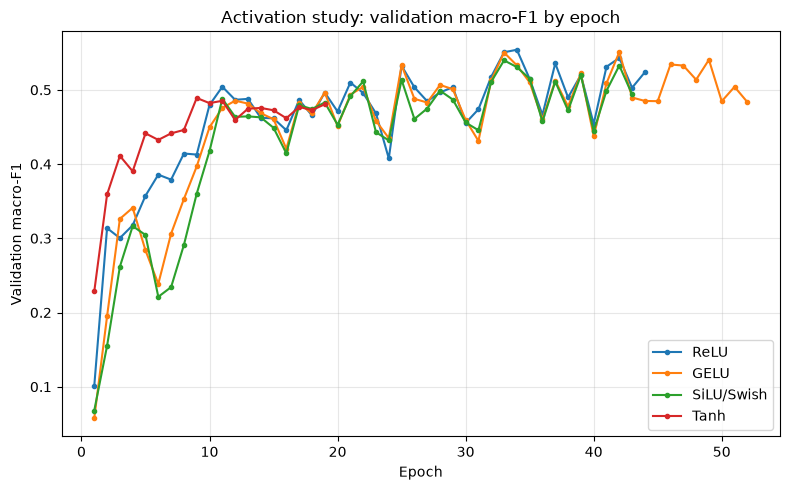

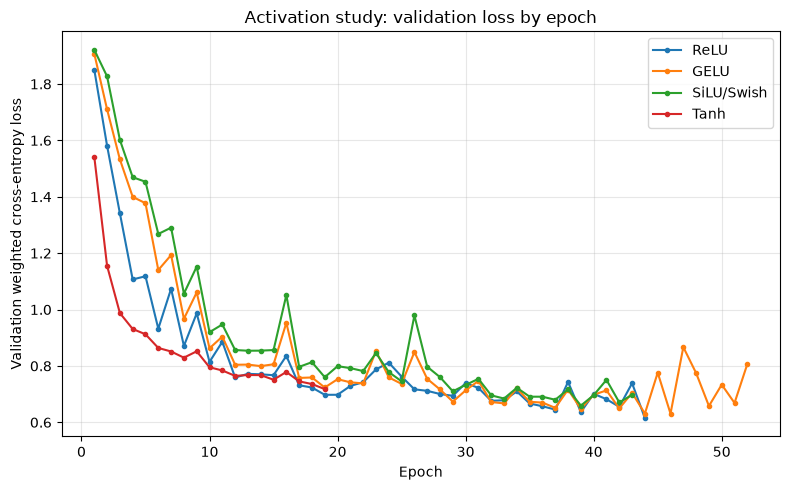

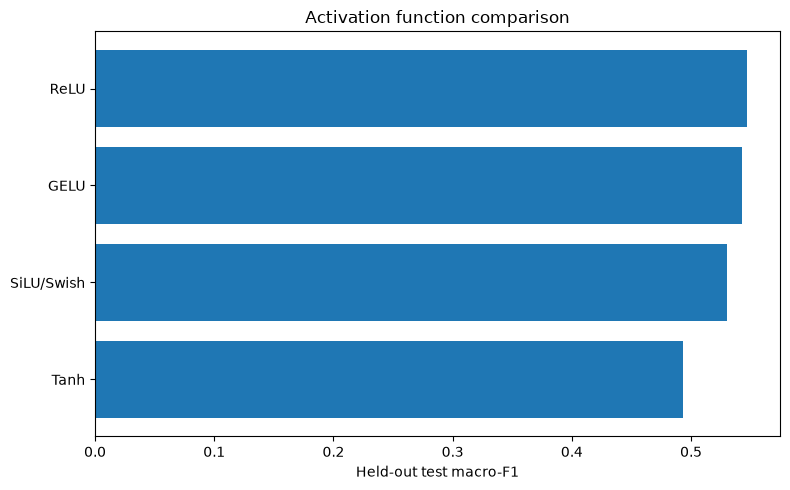

In [7]:
plt.figure(figsize=(8, 5))
for activation, g in activation_history.groupby("activation", sort=False):
    plt.plot(g["epoch"], g["val_macro_f1"], marker="o", linewidth=1.5, markersize=3, label=activation)
plt.xlabel("Epoch")
plt.ylabel("Validation macro-F1")
plt.title("Activation study: validation macro-F1 by epoch")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(FIG_LEARNING_CURVES_DIR / "extra_activation_val_macro_f1_curves.png", dpi=150, bbox_inches="tight")
plt.show()

plt.figure(figsize=(8, 5))
for activation, g in activation_history.groupby("activation", sort=False):
    plt.plot(g["epoch"], g["val_loss"], marker="o", linewidth=1.5, markersize=3, label=activation)
plt.xlabel("Epoch")
plt.ylabel("Validation weighted cross-entropy loss")
plt.title("Activation study: validation loss by epoch")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(FIG_LEARNING_CURVES_DIR / "extra_activation_val_loss_curves.png", dpi=150, bbox_inches="tight")
plt.show()

plt.figure(figsize=(8, 5))
plot_df = activation_comparison.sort_values("test_macro_f1", ascending=True)
plt.barh(plot_df["activation"], plot_df["test_macro_f1"])
plt.xlabel("Held-out test macro-F1")
plt.title("Activation function comparison")
plt.tight_layout()
plt.savefig(FIG_MODEL_COMPLEXITY_DIR / "extra_activation_test_macro_f1_bar.png", dpi=150, bbox_inches="tight")
plt.show()

## Final Comparison Table

The table below is generated from the current notebook run. Test metrics come from `DATA_PATH_TEST`, not from an internal split of the sampled/stratified dataset.

In [8]:
comparison_columns = [
    "activation",
    "test_accuracy",
    "test_macro_f1",
    "test_balanced_accuracy",
    "best_val_accuracy",
    "best_val_macro_f1",
    "best_val_balanced_accuracy",
    "best_epoch",
    "epochs_run",
    "epoch_to_95pct_best_val_macro_f1",
    "last5_val_macro_f1_std",
    "fit_time_sec",
    "predict_time_sec",
]
activation_comparison[comparison_columns].round(4)


,activation,test_accuracy,test_macro_f1,test_balanced_accuracy,best_val_accuracy,best_val_macro_f1,best_val_balanced_accuracy,best_epoch,epochs_run,epoch_to_95pct_best_val_macro_f1,last5_val_macro_f1_std,fit_time_sec,predict_time_sec
0,ReLU,0.6464,0.5473,0.6868,0.6512,0.5540,0.7003,34,44,25,0.0313,3.1783,0.2470
1,GELU,0.6347,0.5424,0.7055,0.6360,0.5509,0.7294,42,52,25,0.0210,4.4851,0.2883
2,SiLU/Swish,0.6079,0.5303,0.6995,0.6155,0.5397,0.7226,33,43,25,0.0303,3.4350,0.3457
3,Tanh,0.5804,0.4930,0.6486,0.5820,0.4890,0.6464,9,19,9,0.0063,1.4188,0.3152


## Brief Analysis: Convergence Speed, Stability, and Trade-offs

The following cell generates a concise interpretation from the current run. Macro-F1 is the primary comparison metric because Covertype is multiclass and imbalanced. Balanced accuracy is included to evaluate average recall across classes.

In [9]:
best_macro = activation_comparison.sort_values("test_macro_f1", ascending=False).iloc[0]
best_accuracy = activation_comparison.sort_values("test_accuracy", ascending=False).iloc[0]
best_balanced = activation_comparison.sort_values("test_balanced_accuracy", ascending=False).iloc[0]
fastest = activation_comparison.sort_values("epoch_to_95pct_best_val_macro_f1", ascending=True).iloc[0]
stablest = activation_comparison.sort_values("last5_val_macro_f1_std", ascending=True).iloc[0]

analysis_text = f"""
Best overall macro-F1: {best_macro['activation']} achieved the strongest held-out test macro-F1 \
({best_macro['test_macro_f1']:.4f}) on DATA_PATH_TEST. This is the primary operating-point metric because \
macro-F1 prevents the larger Covertype classes from dominating the assessment.

Overall accuracy: {best_accuracy['activation']} achieved the highest test accuracy \
({best_accuracy['test_accuracy']:.4f}). Accuracy is useful for summarizing total correctness, but it should not \
be interpreted alone because the class distribution is imbalanced.

Balanced recall behavior: {best_balanced['activation']} achieved the highest balanced accuracy \
({best_balanced['test_balanced_accuracy']:.4f}), indicating the best average recall across classes under this \
fixed training protocol.

Convergence speed: {fastest['activation']} reached 95% of its own best validation macro-F1 earliest, at epoch \
{int(fastest['epoch_to_95pct_best_val_macro_f1'])}. This suggests faster practical convergence under plain SGD, \
although final test quality should still determine the selected activation.

Stability: {stablest['activation']} had the lowest last-five-epoch validation macro-F1 standard deviation \
({stablest['last5_val_macro_f1_std']:.4f}), suggesting the smoothest late-training validation behavior. Higher \
late-epoch variation may reflect SGD noise, sensitivity to the fixed learning rate, or class-imbalance effects.

Trade-off summary: because the architecture, preprocessing, class weighting, L2 regularization, batch size, learning \
rate, early stopping, and plain SGD optimizer are fixed, differences can be attributed mainly to the activation \
function. ReLU-style activations often optimize efficiently with SGD, while smoother activations such as GELU and \
SiLU/Swish may require different learning rates, normalization, or adaptive optimizers to show their usual advantages; \
those changes are intentionally outside this controlled comparison.
"""
print(analysis_text)



Best overall macro-F1: ReLU achieved the strongest held-out test macro-F1 (0.5473) on DATA_PATH_TEST. This is the primary operating-point metric because macro-F1 prevents the larger Covertype classes from dominating the assessment.

Overall accuracy: ReLU achieved the highest test accuracy (0.6464). Accuracy is useful for summarizing total correctness, but it should not be interpreted alone because the class distribution is imbalanced.

Balanced recall behavior: GELU achieved the highest balanced accuracy (0.7055), indicating the best average recall across classes under this fixed training protocol.

Convergence speed: Tanh reached 95% of its own best validation macro-F1 earliest, at epoch 9. This suggests faster practical convergence under plain SGD, although final test quality should still determine the selected activation.

Stability: Tanh had the lowest last-five-epoch validation macro-F1 standard deviation (0.0063), suggesting the smoothest late-training validation behavior. High